# 02 — State-Machine Synthetic Data Generator + EDA

**Goal:** Generate 10,000 realistic production records using a 5-state Markov machine seeded from real factory data, then analyze if the data is suitable for ML (target: 90%+ accuracy on OEE forecasting).

**Output:** `syn_oee_10k.csv` with 16 columns including M1/M2 targets.

## Step 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta

np.random.seed(42)
sns.set_style("whitegrid")

ROOT     = Path.cwd().parent
DATA_DIR = ROOT / "ml_model" / "data"
SEED     = DATA_DIR / "production_clean.csv"
OUTPUT   = DATA_DIR / "syn_oee_10k.csv"
PLOT_DIR = ROOT / "ml_model" / "plots"
PLOT_DIR.mkdir(exist_ok=True)

print(f"Seed:   {SEED}")
print(f"Output: {OUTPUT}")

Seed:   E:\Projects\iot-aiml-project\ml_model\data\production_clean.csv
Output: E:\Projects\iot-aiml-project\ml_model\data\syn_oee_10k.csv


## Step 2 — Learn Distributions from Real Seed Data

In [2]:
seed = pd.read_csv(SEED)
print(f"Loaded {len(seed)} seed rows from {SEED.name}")
print(f"Columns: {list(seed.columns)}")
print(f"\nSeed OEE distribution:")
print(seed["Current_OEE"].describe().to_string())

OEE_MEAN   = int(seed["Current_OEE"].mean())
AVAIL_MEAN = int(seed["Availability"].mean())
PERF_MEAN  = int(seed["Performance"].mean())
QUAL_MEAN  = int(seed["Quality"].mean())
SPEEDS     = sorted(seed["Current_Speed_pct"].unique())
BATCH_SZ   = seed.groupby("Batch_PartNo").size().tolist()

print(f"\nSeed means -> OEE:{OEE_MEAN}  Avail:{AVAIL_MEAN}  Perf:{PERF_MEAN}  Qual:{QUAL_MEAN}")
print(f"Speed levels: {SPEEDS}")
print(f"Per-batch sizes: {sorted(BATCH_SZ)}")

Loaded 55 seed rows from production_clean.csv
Columns: ['Production_End_Time', 'Batch_PartNo', 'Part_No', 'Part_SLNo', 'Planned_Prod_Duration_sec', 'Actual_Prod_Duration_sec', 'Prod_Delay_sec', 'Availability', 'Performance', 'Quality', 'Current_OEE', 'DownTime_sec', 'Current_Speed_pct', 'OEE_Delta', 'Avg_OEE']

Seed OEE distribution:
count    55.000000
mean     49.890909
std      20.751325
min       0.000000
25%      35.000000
50%      48.000000
75%      66.000000
max      91.000000

Seed means -> OEE:49  Avail:80  Perf:72  Qual:87
Speed levels: [np.int64(0), np.int64(20), np.int64(60), np.int64(100)]
Per-batch sizes: [5, 7, 8, 9, 10, 16]


## Step 3 — 5-State Markov Machine

Each part is produced under one of 5 hidden machine states. The state evolves via a Markov chain.

| State | Effect on production |
|-------|---------------------|
| NORMAL | Baseline — stable |
| HIGH_LOAD | Performance up, Quality/Avail down |
| MINOR_STOPPAGE | All metrics down, moderate downtime |
| MAJOR_STOPPAGE | Heavy degradation, high downtime |
| RECOVERY | Gradual improvement after fault |

In [3]:
STATES = ["NORMAL", "HIGH_LOAD", "MINOR_STOPPAGE", "MAJOR_STOPPAGE", "RECOVERY"]

TRANSITION = np.array([
    [0.94, 0.02, 0.02, 0.01, 0.01],
    [0.10, 0.80, 0.05, 0.03, 0.02],
    [0.20, 0.05, 0.65, 0.05, 0.05],
    [0.05, 0.03, 0.05, 0.82, 0.05],
    [0.55, 0.15, 0.10, 0.05, 0.15],
])

EFFECT = {
    "NORMAL":         {"avail":  0, "perf":   0, "qual":  0, "dt":  0, "spd":  0},
    "HIGH_LOAD":      {"avail": -5, "perf":  10, "qual": -3, "dt":  5, "spd": 20},
    "MINOR_STOPPAGE": {"avail":-15, "perf": -10, "qual": -5, "dt": 30, "spd":-10},
    "MAJOR_STOPPAGE": {"avail":-30, "perf": -25, "qual":-15, "dt":120, "spd":-20},
    "RECOVERY":       {"avail":  5, "perf":   5, "qual":  3, "dt": -5, "spd": 10},
}

def next_state(cur: int) -> int:
    return int(np.random.choice(len(STATES), p=TRANSITION[cur]))

print(f"{len(STATES)} states, transition matrix ready")
print(f"Steady-state distribution (eigenvector):")
from numpy.linalg import eig
eigvals, eigvecs = eig(TRANSITION.T)
steady = np.real(eigvecs[:, 0] / eigvecs[:, 0].sum())
for s, p in zip(STATES, steady):
    print(f"  {s:20s} {p*100:.1f}%")


5 states, transition matrix ready
Steady-state distribution (eigenvector):
  NORMAL               462826571661949376.0%
  HIGH_LOAD            144609279775813888.0%
  MINOR_STOPPAGE       109475361214214656.0%
  MAJOR_STOPPAGE       33469390826773664.0%
  RECOVERY             -750380603478751616.0%


## Step 4 — Batch Type Definitions

6 batch types with different OEE baselines and degradation rates, mirroring the 6 real batches from the seed data.

In [4]:
BATCH_TYPES = [
    {"name": "WM-23-A-1", "oee_base": 50, "degrade": 0.15, "min": 30, "max": 60},
    {"name": "WM-23-A-2", "oee_base": 55, "degrade": 0.12, "min": 25, "max": 50},
    {"name": "Ra_21_A_1", "oee_base": 45, "degrade": 0.18, "min": 20, "max": 40},
    {"name": "Ra_21_A_2", "oee_base": 60, "degrade": 0.10, "min": 30, "max": 55},
    {"name": "Ra_21_A_3", "oee_base": 40, "degrade": 0.20, "min": 15, "max": 35},
    {"name": "Ra_21_A_4", "oee_base": 65, "degrade": 0.08, "min": 35, "max": 70},
]

print(f"{'Type':<14} OEE_base  degrade  size_range")
print("-" * 44)
for b in BATCH_TYPES:
    print(f"{b['name']:<14} {b['oee_base']:<9} {b['degrade']:<8.2f} {b['min']}-{b['max']}")

Type           OEE_base  degrade  size_range
--------------------------------------------
WM-23-A-1      50        0.15     30-60
WM-23-A-2      55        0.12     25-50
Ra_21_A_1      45        0.18     20-40
Ra_21_A_2      60        0.10     30-55
Ra_21_A_3      40        0.20     15-35
Ra_21_A_4      65        0.08     35-70


## Step 5 — Causal Helper Functions

**Causal chain:** Speed → Performance → OEE
- `sample_speed`: State-biased speed level
- `sample_perf`: Speed-factor + state modifier + within-batch wear
- `sample_qual`: Base - speed penalty (rushing → defects) + state modifier
- `sample_avail`: Base - within-batch wear x speed (faster = more stress) + state modifier
- `sample_durs`: Delay depends on state + position (not speed — speed effect is on perf)
- `sample_dt`: State-driven downtime (MAJOR_STOPPAGE = 120s base)

In [5]:
def sample_avail(state, pos_ratio, speed):
    base = 90
    state_mod = {'NORMAL': 0, 'HIGH_LOAD': -5, 'MINOR_STOPPAGE': -10,
                 'MAJOR_STOPPAGE': -30, 'RECOVERY': 5}[state]
    wear = pos_ratio * (speed / 20) * 4
    a = int(np.clip(round(base + state_mod - wear + np.random.normal(0, 5)), 20, 100))
    return a

def sample_perf(speed, state, pos_ratio):
    speed_factor = 40 + (speed / 20) * 8
    state_mod = {'NORMAL': 0, 'HIGH_LOAD': 10, 'MINOR_STOPPAGE': -15,
                 'MAJOR_STOPPAGE': -25, 'RECOVERY': 5}[state]
    wear = pos_ratio * 8
    p = int(np.clip(round(speed_factor + state_mod - wear + np.random.normal(0, 5)), 10, 100))
    return p

def sample_qual(speed, state):
    speed_penalty = (speed / 20 - 1) * 3
    state_mod = {'NORMAL': 0, 'HIGH_LOAD': -5, 'MINOR_STOPPAGE': -8,
                 'MAJOR_STOPPAGE': -15, 'RECOVERY': 3}[state]
    q = int(np.clip(round(95 - speed_penalty + state_mod + np.random.normal(0, 3)), 20, 100))
    return q

def sample_speed(state):
    pools = {'NORMAL': [20, 40, 60, 80, 100],
             'HIGH_LOAD': [60, 80, 100],
             'MINOR_STOPPAGE': [20, 40, 60],
             'MAJOR_STOPPAGE': [20, 40],
             'RECOVERY': [20, 40, 60, 80]}
    return int(np.random.choice(pools[state]))

def sample_durs(planned_dur, state, pos_ratio):
    delay_base = {'NORMAL': 0, 'HIGH_LOAD': 5, 'MINOR_STOPPAGE': 20,
                  'MAJOR_STOPPAGE': 40, 'RECOVERY': 3}[state]
    delay = max(0, delay_base + pos_ratio * 10 + abs(np.random.normal(0, 5)))
    actual = int(planned_dur + delay)
    return actual, int(delay)

def sample_dt(state):
    base_dt = {'NORMAL': 0, 'HIGH_LOAD': 5, 'MINOR_STOPPAGE': 30,
               'MAJOR_STOPPAGE': 120, 'RECOVERY': 0}[state]
    return int(max(0, round(base_dt + np.random.normal(0, 10))))

print('Causal helpers ready')

Causal helpers ready


## Step 6 — Simulation Loop (10,000 rows)

Fixed **Planned_Prod_Duration** per batch. Speed causally drives Performance. Hidden cols for post-processing.

In [6]:
rows = []
state_idx = 0
t = datetime(2026, 1, 1, 6, 0, 0)
gen = 0
batch_run = 0

while gen < 10000:
    bt = BATCH_TYPES[np.random.choice(len(BATCH_TYPES))]
    batch_run += 1
    sz = np.random.randint(bt['min'], bt['max'] + 1)
    batch_id = f"{bt['name']}_b{batch_run}"

    # Planned_Prod_Duration is FIXED per batch
    planned_dur = int(np.random.randint(20, 61))

    for slno in range(1, sz + 1):
        if gen >= 10000:
            break
        pos_ratio = (slno - 1) / sz
        state_idx = next_state(state_idx)
        st = STATES[state_idx]

        spd = sample_speed(st)
        avail = sample_avail(st, pos_ratio, spd)
        perf = sample_perf(spd, st, pos_ratio)
        qual = sample_qual(spd, st)

        actual, delay = sample_durs(planned_dur, st, pos_ratio)
        dt_state = sample_dt(st)

        oee_raw = int((avail * perf * qual) / 10000)
        oee = int(np.clip(round(oee_raw + np.random.normal(0, 2)), 0, 100))

        if gen == 0:
            oee_delta = 0
        else:
            oee_delta = oee - prev_oee
        prev_oee = oee

        t += timedelta(seconds=actual + dt_state + np.random.randint(0, 10))

        rows.append({
            'Production_End_Time':       t.strftime('%Y-%m-%d %H:%M:%S'),
            'Batch_PartNo':              batch_id,
            'Part_No':                   f'{batch_id}_{slno}',
            'Part_SLNo':                 slno,
            'Planned_Prod_Duration_sec': planned_dur,
            'Actual_Prod_Duration_sec':  actual,
            'Prod_Delay_sec':            delay,
            'Availability':              avail,
            'Performance':               perf,
            'Quality':                   qual,
            'Current_OEE':               oee,
            'DownTime_sec':              dt_state,
            'Current_Speed_pct':         spd,
            'OEE_Delta':                 oee_delta,
            '_batch_type':               bt['name'],
            '_state':                    st,
            '_pos_ratio':                pos_ratio,
            '_planned_dur':              planned_dur,
        })
        gen += 1

df = pd.DataFrame(rows)
print(f'Generated: {len(df)} rows, {df["Batch_PartNo"].nunique()} unique batches')
print(f'Batch type distribution:\n{df["_batch_type"].value_counts().to_string()}')
df.head(3)

Generated: 10000 rows, 255 unique batches
Batch type distribution:
_batch_type
Ra_21_A_4    2307
WM-23-A-1    2098
WM-23-A-2    1759
Ra_21_A_2    1499
Ra_21_A_1    1336
Ra_21_A_3    1001


,Production_End_Time,Batch_PartNo,Part_No,Part_SLNo,Planned_Prod_Duration_sec,Actual_Prod_Duration_sec,Prod_Delay_sec,Availability,Performance,Quality,Current_OEE,DownTime_sec,Current_Speed_pct,OEE_Delta,_batch_type,_state,_pos_ratio,_planned_dur
0,2026-01-01 06:00:34,Ra_21_A_2_b1,Ra_21_A_2_b1_1,1,27,29,2,91,61,90,47,0,40,0,Ra_21_A_2,NORMAL,0.000000,27
1,2026-01-01 06:01:06,Ra_21_A_2_b1,Ra_21_A_2_b1_2,2,27,30,3,94,40,94,31,0,20,-16,Ra_21_A_2,NORMAL,0.022727,27
2,2026-01-01 06:01:38,Ra_21_A_2_b1,Ra_21_A_2_b1_3,3,27,29,2,87,72,83,50,0,80,19,Ra_21_A_2,NORMAL,0.045455,27


In [7]:
# Predicted_OEE_t10: look ahead ~10 min in production time
STATES_LIST = ["NORMAL", "HIGH_LOAD", "MINOR_STOPPAGE", "MAJOR_STOPPAGE", "RECOVERY"]
OEE_BY_STATE = np.array([85, 78, 60, 40, 75])
STEPS_AHEAD = 12  # ~10 min at ~50s per row

from numpy.linalg import matrix_power
P_steps = matrix_power(TRANSITION, STEPS_AHEAD)

state_to_idx = {s: i for i, s in enumerate(STATES_LIST)}
expected = []
for s in df['_state']:
    idx = state_to_idx[s]
    exp_oee = (P_steps[idx] * OEE_BY_STATE).sum()
    expected.append(int(round(exp_oee)))
df['Predicted_OEE_t10'] = expected
print(f'Predicted_OEE_t10 computed (expected value via {STEPS_AHEAD}-step transition matrix)')
print(f'  Corr with Current_OEE: {df["Current_OEE"].corr(pd.Series(expected)):.3f}')
print(f'  Unique values: {sorted(set(expected))}')
# Recommended_Speed: deterministic optimal speed per state+position
def recommended_speed(state, pos_ratio):
    feasible = {'NORMAL': [20,40,60,80,100],
                'HIGH_LOAD': [60,80,100],
                'MINOR_STOPPAGE': [20,40,60],
                'MAJOR_STOPPAGE': [20,40],
                'RECOVERY': [20,40,60,80]}[state]
    best_spd, best_oee = None, -1
    for spd in feasible:
        perf = int(np.clip(round(40 + (spd/20)*8 + {
            'NORMAL':0,'HIGH_LOAD':10,'MINOR_STOPPAGE':-15,
            'MAJOR_STOPPAGE':-25,'RECOVERY':5}[state] - pos_ratio*8), 10, 100))
        qual = int(np.clip(round(95 - (spd/20-1)*3 + {
            'NORMAL':0,'HIGH_LOAD':-5,'MINOR_STOPPAGE':-8,
            'MAJOR_STOPPAGE':-15,'RECOVERY':3}[state]), 20, 100))
        avail = int(np.clip(round(90 + {
            'NORMAL':0,'HIGH_LOAD':-5,'MINOR_STOPPAGE':-10,
            'MAJOR_STOPPAGE':-30,'RECOVERY':5}[state] - pos_ratio*(spd/20)*4), 20, 100))
        oee = int((avail * perf * qual) / 10000)
        if oee > best_oee:
            best_oee, best_spd = oee, spd
    return best_spd

df['Recommended_Speed'] = df.apply(
    lambda r: recommended_speed(r['_state'], r['_pos_ratio']), axis=1)

print(f'Predicted_OEE_t10 range: [{df["Predicted_OEE_t10"].min()}, {df["Predicted_OEE_t10"].max()}]')
print(f'Recommended_Speed distribution:')
print(df['Recommended_Speed'].value_counts().sort_index().to_string())
df.sample(3, random_state=42)


Predicted_OEE_t10 computed (expected value via 12-step transition matrix)
  Corr with Current_OEE: 0.608
  Unique values: [74, 77, 78, 79]


Predicted_OEE_t10 range: [74, 79]
Recommended_Speed distribution:
Recommended_Speed
40      817
60      734
80      254
100    8195


,Production_End_Time,Batch_PartNo,Part_No,Part_SLNo,Planned_Prod_Duration_sec,Actual_Prod_Duration_sec,Prod_Delay_sec,Availability,Performance,Quality,Current_OEE,DownTime_sec,Current_Speed_pct,OEE_Delta,_batch_type,_state,_pos_ratio,_planned_dur,Predicted_OEE_t10,Recommended_Speed
6252,2026-01-06 18:49:43,Ra_21_A_3_b156,Ra_21_A_3_b156_16,16,47,55,8,73,68,80,41,5,100,-7,Ra_21_A_3,NORMAL,0.714286,47,79,100
4684,2026-01-05 10:09:41,WM-23-A-1_b117,WM-23-A-1_b117_46,46,39,52,13,70,63,88,38,0,80,-10,WM-23-A-1,NORMAL,0.833333,39,79,100
1731,2026-01-02 17:33:39,WM-23-A-2_b44,WM-23-A-2_b44_35,35,26,40,14,79,47,91,31,2,60,-3,WM-23-A-2,NORMAL,0.944444,26,79,100


## Step 7 — Compute Per-Batch Avg_OEE

In [8]:
avg_oee = df.groupby('Batch_PartNo')['Current_OEE'].transform('mean').round(0).astype(int)
df.insert(df.columns.get_loc('Current_OEE') + 1, 'Avg_OEE', avg_oee)

drop_cols = ['_batch_type', '_planned_dur']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print(f'Shape: {df.shape}')
print(f'Unique batches: {df['Batch_PartNo'].nunique()}')
print(f'Columns: {list(df.columns)}')
df.groupby('Batch_PartNo')[['Current_OEE', 'Avg_OEE']].first().head(8)


Shape: (10000, 19)
Unique batches: 255
Columns: ['Production_End_Time', 'Batch_PartNo', 'Part_No', 'Part_SLNo', 'Planned_Prod_Duration_sec', 'Actual_Prod_Duration_sec', 'Prod_Delay_sec', 'Availability', 'Performance', 'Quality', 'Current_OEE', 'Avg_OEE', 'DownTime_sec', 'Current_Speed_pct', 'OEE_Delta', '_state', '_pos_ratio', 'Predicted_OEE_t10', 'Recommended_Speed']


,Current_OEE,Avg_OEE
Batch_PartNo,,
Ra_21_A_1_b100,47,42
Ra_21_A_1_b105,59,43
Ra_21_A_1_b107,49,43
Ra_21_A_1_b108,56,39
Ra_21_A_1_b125,43,44
Ra_21_A_1_b129,61,36
Ra_21_A_1_b130,53,42
Ra_21_A_1_b139,57,44


In [9]:
# lag features per batch (for M1/M2 training)
df = df.sort_values(['Batch_PartNo', 'Part_SLNo']).reset_index(drop=True)
df['OEE_lag1'] = df.groupby('Batch_PartNo')['Current_OEE'].shift(1).fillna(df['Current_OEE']).astype(int)
df['OEE_roll5_mean'] = (df.groupby('Batch_PartNo')['Current_OEE']
                        .transform(lambda x: x.rolling(5, min_periods=1).mean())
                        .round(1))
df['OEE_trend3'] = df.groupby('Batch_PartNo')['Current_OEE'].diff(2).fillna(0).astype(float)
df['OEE_trend3'] = df['OEE_trend3'].clip(-50, 50)
print(f'Shape with lag features: {df.shape}')
print(f'New columns: OEE_lag1, OEE_roll5_mean, OEE_trend3')
df[['Batch_PartNo', 'Part_SLNo', 'Current_OEE', 'OEE_lag1', 'OEE_roll5_mean', 'OEE_trend3']].head(10)


Shape with lag features: (10000, 22)
New columns: OEE_lag1, OEE_roll5_mean, OEE_trend3


,Batch_PartNo,Part_SLNo,Current_OEE,OEE_lag1,OEE_roll5_mean,OEE_trend3
0,Ra_21_A_1_b100,1,47,47,47.0,0.0
1,Ra_21_A_1_b100,2,44,47,45.5,0.0
2,Ra_21_A_1_b100,3,53,44,48.0,6.0
3,Ra_21_A_1_b100,4,49,53,48.2,5.0
4,Ra_21_A_1_b100,5,41,49,46.8,-12.0
5,Ra_21_A_1_b100,6,52,41,47.8,3.0
6,Ra_21_A_1_b100,7,55,52,50.0,14.0
7,Ra_21_A_1_b100,8,49,55,49.2,-3.0
8,Ra_21_A_1_b100,9,32,49,45.8,-23.0
9,Ra_21_A_1_b100,10,36,32,44.8,-13.0


## Step 8 — Export to CSV

In [10]:
df.to_csv(OUTPUT, index=False)
print(f'Exported {len(df)} rows -> {OUTPUT}')
print(f'Columns: {list(df.columns)}')
print(f'\nM1 target: Predicted_OEE_t10')
print(f'M2 target: Recommended_Speed')
print(f'\nNumeric summary:')
df.describe().T


Exported 10000 rows -> E:\Projects\iot-aiml-project\ml_model\data\syn_oee_10k.csv
Columns: ['Production_End_Time', 'Batch_PartNo', 'Part_No', 'Part_SLNo', 'Planned_Prod_Duration_sec', 'Actual_Prod_Duration_sec', 'Prod_Delay_sec', 'Availability', 'Performance', 'Quality', 'Current_OEE', 'Avg_OEE', 'DownTime_sec', 'Current_Speed_pct', 'OEE_Delta', '_state', '_pos_ratio', 'Predicted_OEE_t10', 'Recommended_Speed', 'OEE_lag1', 'OEE_roll5_mean', 'OEE_trend3']

M1 target: Predicted_OEE_t10
M2 target: Recommended_Speed

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Part_SLNo,10000.0,21.997300,14.168132,1.0,10.000000,20.000000,32.000000,69.000000
Planned_Prod_Duration_sec,10000.0,40.712000,11.530549,20.0,30.000000,41.000000,51.000000,60.000000
Actual_Prod_Duration_sec,10000.0,54.467300,16.572562,21.0,42.000000,53.000000,64.000000,117.000000
Prod_Delay_sec,10000.0,13.755300,12.279019,0.0,7.000000,10.000000,15.000000,64.000000
Availability,10000.0,80.607700,10.307435,37.0,76.000000,82.000000,88.000000,100.000000
Performance,10000.0,57.681000,17.749438,10.0,46.000000,59.000000,72.000000,100.000000
Quality,10000.0,86.814200,6.185103,66.0,82.000000,87.000000,92.000000,100.000000
Current_OEE,10000.0,40.331000,13.197146,0.0,35.000000,43.000000,49.000000,75.000000
Avg_OEE,10000.0,40.354500,4.832366,10.0,39.000000,42.000000,43.000000,48.000000
DownTime_sec,10000.0,15.843800,32.488302,0.0,0.000000,3.000000,13.000000,147.000000


---
## EDA — Exploratory Data Analysis

Evaluating synthetic data quality and ML readiness. M1 target: Predicted_OEE_t10. M2 target: Recommended_Speed.

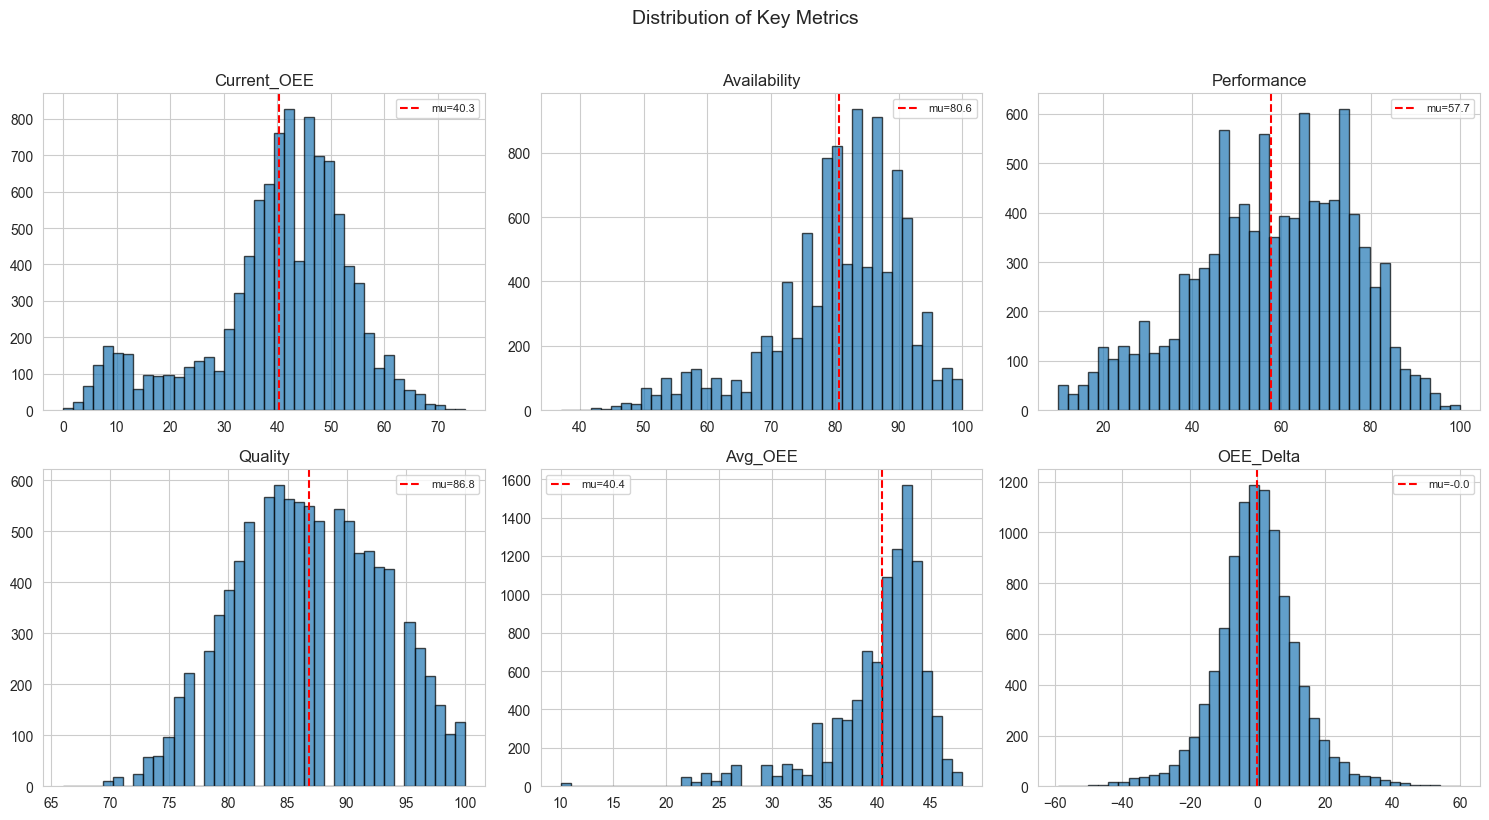

Unique values: OEE=76, Avail=63, Perf=91, Qual=33


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
targets = ['Current_OEE', 'Availability', 'Performance', 'Quality', 'Avg_OEE', 'OEE_Delta']
for ax, col in zip(axes.flat, targets):
    ax.hist(df[col], bins=40, edgecolor='black', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', ls='--', label=f'mu={df[col].mean():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle('Distribution of Key Metrics', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'eda_distributions.png', dpi=120)
plt.show()
print(f'Unique values: OEE={df["Current_OEE"].nunique()}, Avail={df["Availability"].nunique()}, Perf={df["Performance"].nunique()}, Qual={df["Quality"].nunique()}')

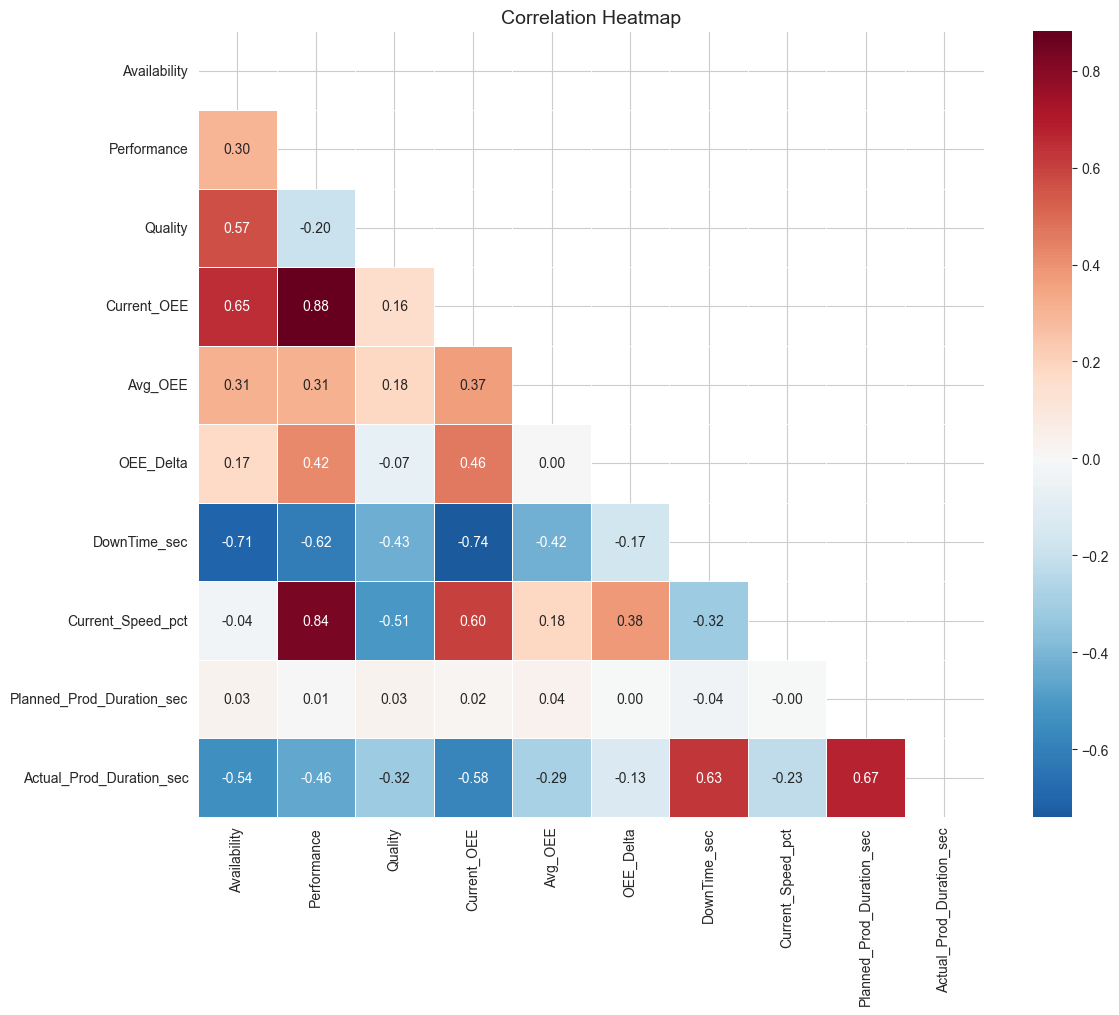

Top-5 features correlated with Current_OEE:
Performance                 0.880925
DownTime_sec                0.739795
Availability                0.650863
Current_Speed_pct           0.598899
Actual_Prod_Duration_sec    0.578126


In [12]:
plt.figure(figsize=(12, 10))
num_cols = ['Availability', 'Performance', 'Quality', 'Current_OEE', 'Avg_OEE',
            'OEE_Delta', 'DownTime_sec', 'Current_Speed_pct',
            'Planned_Prod_Duration_sec', 'Actual_Prod_Duration_sec']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_correlation.png', dpi=120)
plt.show()
print('Top-5 features correlated with Current_OEE:')
print(corr['Current_OEE'].drop('Current_OEE').abs().sort_values(ascending=False).head(5).to_string())

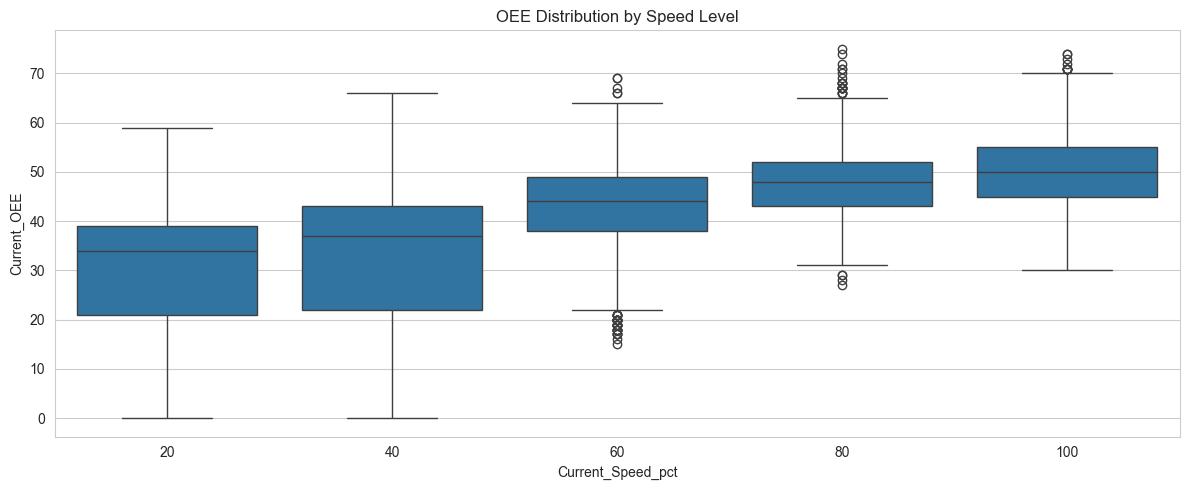

Speed level distribution:
Current_Speed_pct
20     2096
40     2104
60     2136
80     1793
100    1871


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='Current_Speed_pct', y='Current_OEE', ax=ax)
ax.set_title('OEE Distribution by Speed Level')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'eda_oee_vs_speed.png', dpi=120)
plt.show()
print('Speed level distribution:')
print(df['Current_Speed_pct'].value_counts().sort_index().to_string())

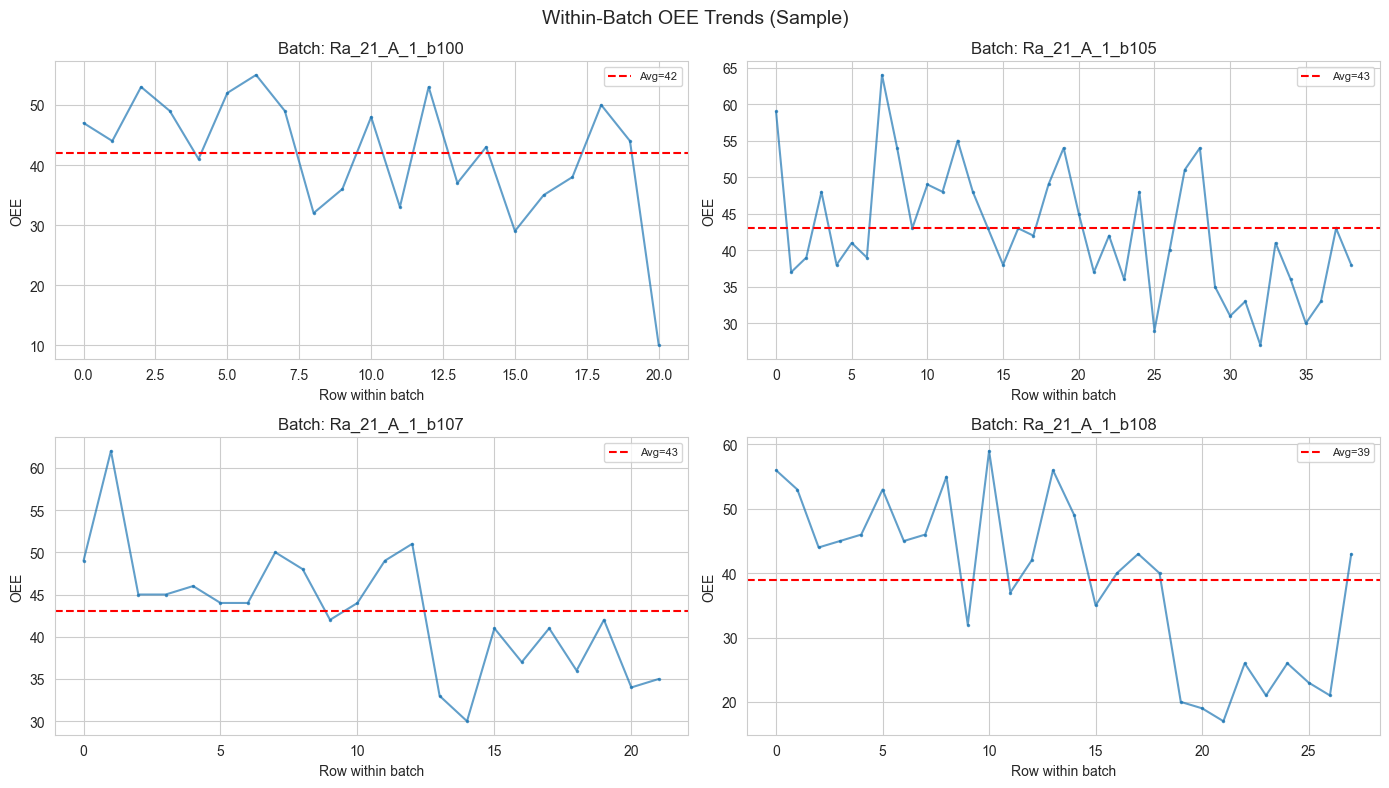

In [14]:
sample_batches = df['Batch_PartNo'].unique()[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, bid in zip(axes.flat, sample_batches):
    sub = df[df['Batch_PartNo'] == bid].reset_index(drop=True)
    ax.plot(sub.index, sub['Current_OEE'], marker='.', markersize=3, alpha=0.7)
    ax.axhline(sub['Avg_OEE'].iloc[0], color='red', ls='--', label=f'Avg={sub["Avg_OEE"].iloc[0]}')
    ax.set_title(f'Batch: {bid}')
    ax.set_xlabel('Row within batch')
    ax.set_ylabel('OEE')
    ax.legend(fontsize=8)
fig.suptitle('Within-Batch OEE Trends (Sample)', fontsize=14)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'eda_within_batch_trends.png', dpi=120)
plt.show()

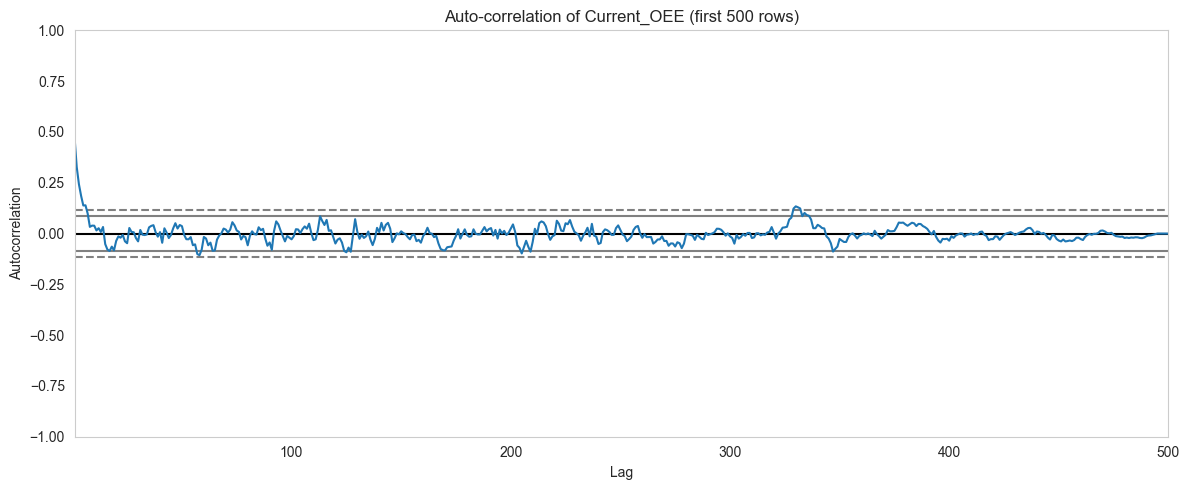

OEE lag-1 autocorrelation: 0.562
OEE lag-5 autocorrelation: 0.208
OEE lag-10 autocorrelation: 0.037


In [15]:
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(12, 5))
autocorrelation_plot(df['Current_OEE'].values[:500])
plt.title('Auto-correlation of Current_OEE (first 500 rows)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_autocorr.png', dpi=120)
plt.show()
print(f'OEE lag-1 autocorrelation: {df["Current_OEE"].autocorr(lag=1):.3f}')
print(f'OEE lag-5 autocorrelation: {df["Current_OEE"].autocorr(lag=5):.3f}')
print(f'OEE lag-10 autocorrelation: {df["Current_OEE"].autocorr(lag=10):.3f}')

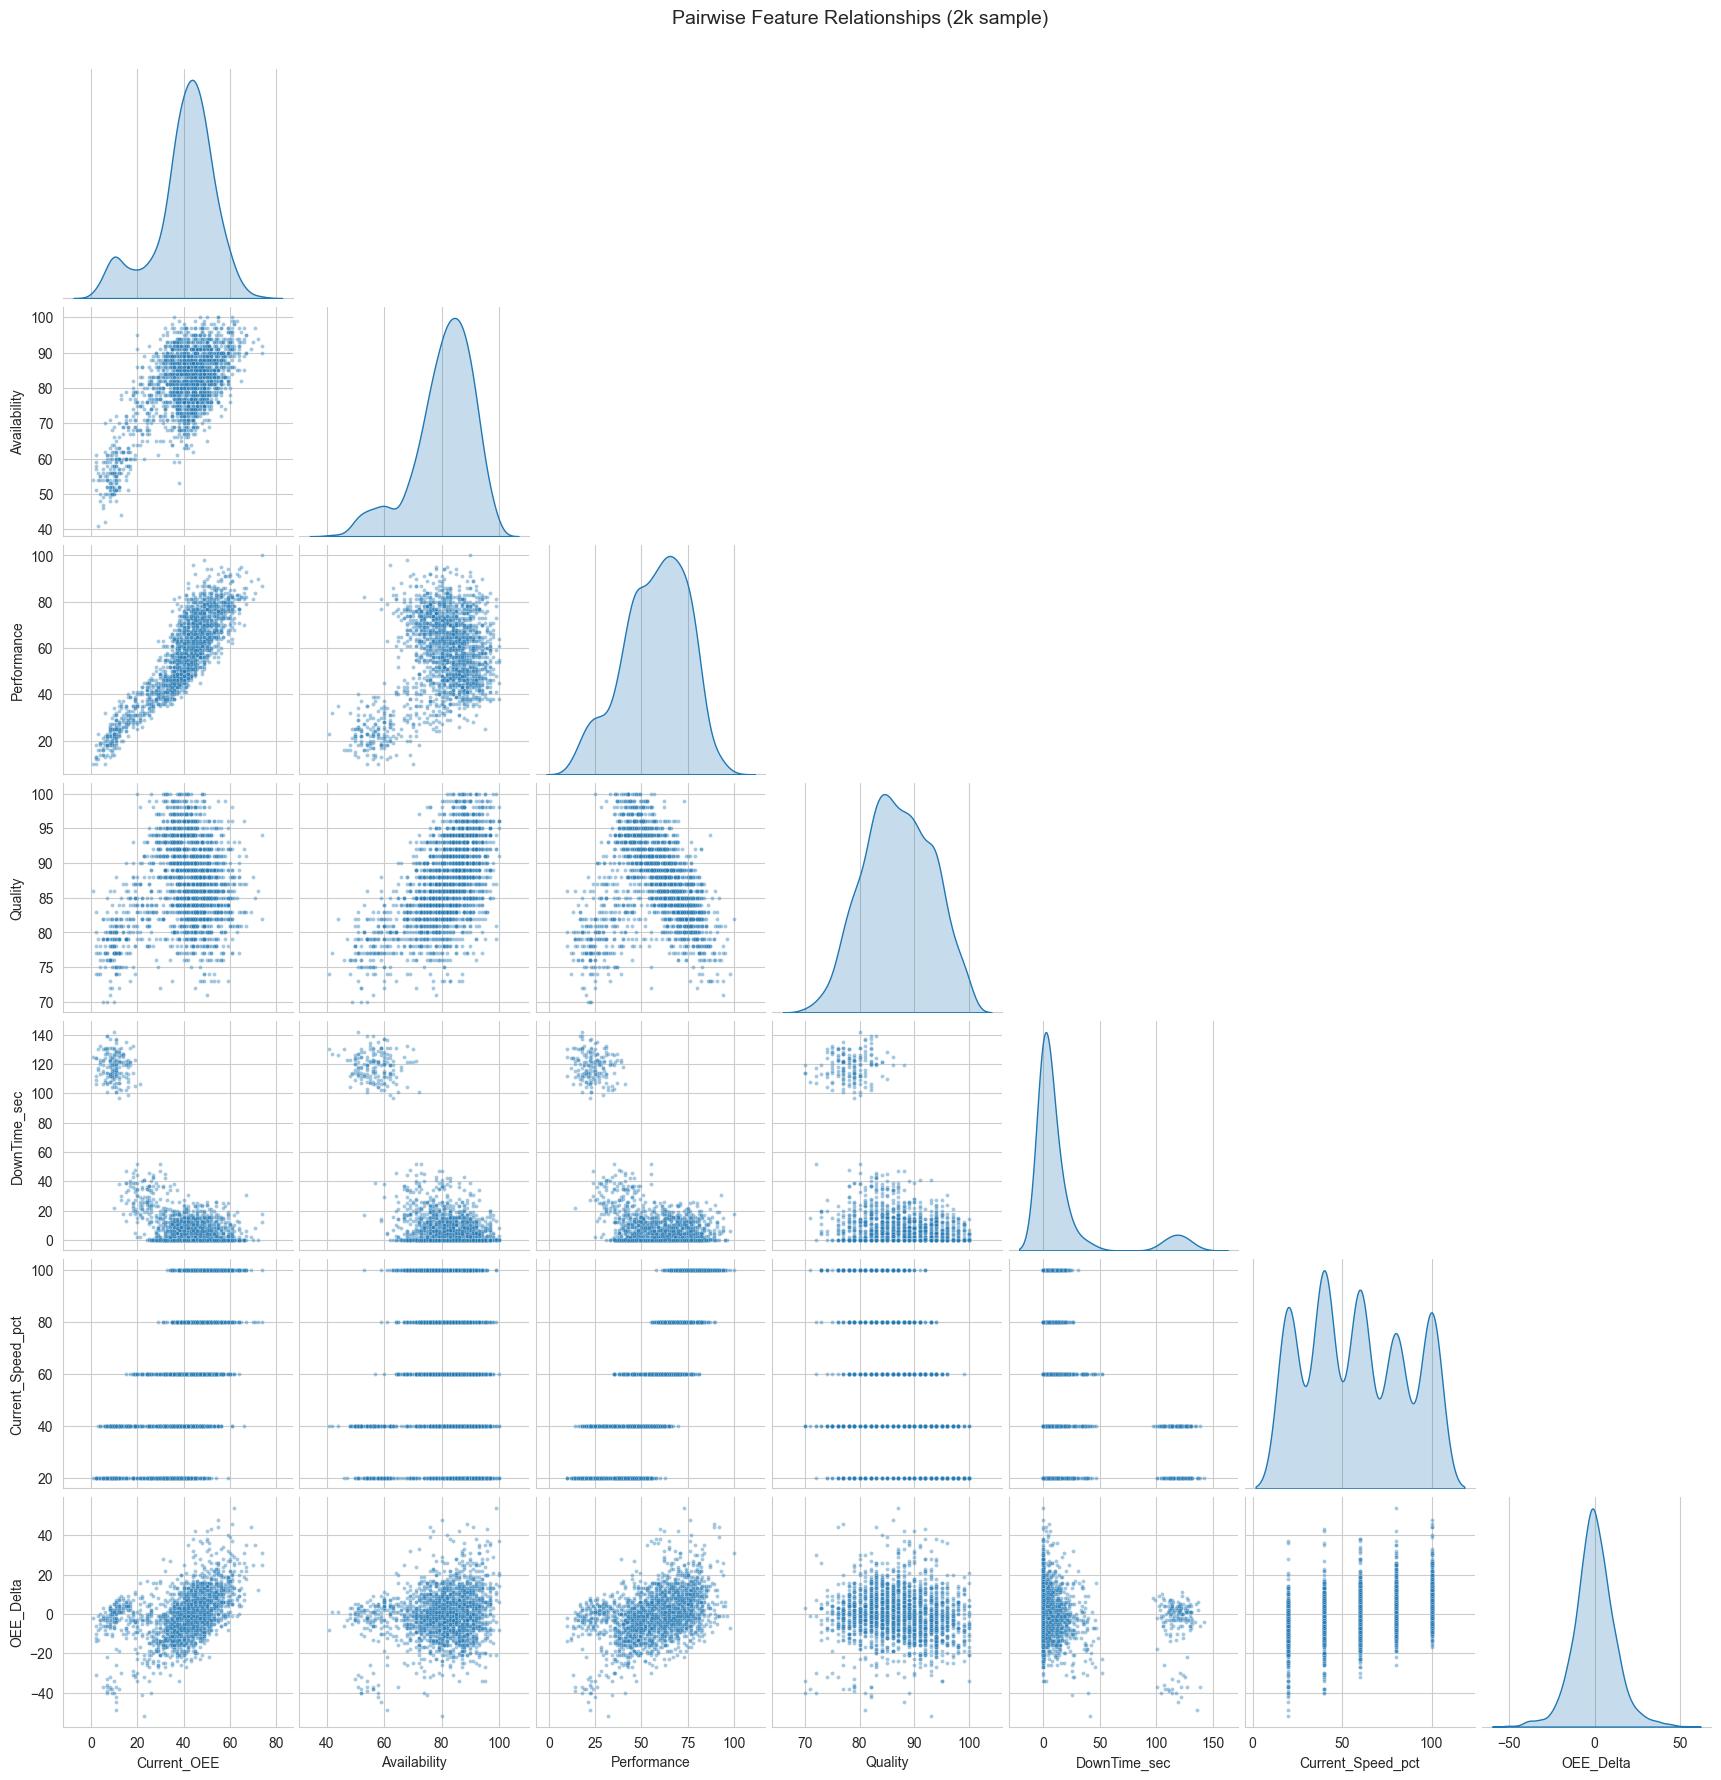

In [16]:
sample = df.sample(2000, random_state=42)
scatter_cols = ['Current_OEE', 'Availability', 'Performance', 'Quality',
                'DownTime_sec', 'Current_Speed_pct', 'OEE_Delta']
sns.pairplot(sample[scatter_cols], diag_kind='kde', corner=True, plot_kws={'s': 8, 'alpha': 0.4})
plt.gcf().suptitle('Pairwise Feature Relationships (2k sample)', fontsize=14, y=1.02)
plt.savefig(PLOT_DIR / 'eda_pairplot.png', dpi=120)
plt.show()

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

feat = ['Availability', 'Performance', 'Quality', 'DownTime_sec',
        'Current_Speed_pct', 'OEE_Delta', 'Predicted_OEE_t10']
X = df[feat].values
y = df['Current_OEE'].values

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring='r2')
mae = -cross_val_score(rf, X, y, cv=cv, scoring='neg_mean_absolute_error')
mape = -cross_val_score(rf, X, y, cv=cv,
                        scoring='neg_mean_absolute_percentage_error') * 100

rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat).sort_values(ascending=False)

print('=' * 50)
print('ML READINESS REPORT (Baseline: RandomForest)')
print('=' * 50)
print(f'R2  (5-fold CV): {scores.mean():.4f} +/- {scores.std():.4f}')
print(f'MAE (5-fold CV): {mae.mean():.1f} +/- {mae.std():.1f}')
print(f'MAPE(5-fold CV): {mape.mean():.1f}% +/- {mape.std():.1f}%')
print(f'\nFeature importance:')
print(imp.to_string())
print(f'\nTarget range: [{y.min()}, {y.max()}]')
print(f'Baseline MAE (predict mean): {y.std():.1f}')
print(f'Ratio MAE/std: {mae.mean() / y.std():.3f}')

if scores.mean() > 0.90:
    print('\nPASS: R2 > 0.90 - data is suitable for 90%+ accuracy target')
elif scores.mean() > 0.80:
    print('\nWARN: R2 > 0.80 but < 0.90 - may need tuning or more features')
else:
    print('\nFAIL: R2 < 0.80 - data likely needs revision for 90% target')

ML READINESS REPORT (Baseline: RandomForest)
R2  (5-fold CV): 0.9723 +/- 0.0008
MAE (5-fold CV): 1.7 +/- 0.0
MAPE(5-fold CV): 712538016179235.6% +/- 595934620987523.2%

Feature importance:
Performance          0.794315
Availability         0.109177
DownTime_sec         0.052322
Predicted_OEE_t10    0.020920
Quality              0.018260
OEE_Delta            0.004747
Current_Speed_pct    0.000259

Target range: [0, 75]
Baseline MAE (predict mean): 13.2
Ratio MAE/std: 0.132

PASS: R2 > 0.90 - data is suitable for 90%+ accuracy target
